# **ZOMATO**

In [ ]:
!pip install requests beautifulsoup4 pandas lxml

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import json

headers = {
    "User-Agent": "Mozilla/5.0"
}

city_areas = {
    "bangalore": ["indiranagar", "whitefield", "koramangala", "btm", "marathahalli", "rs-city"],
    "chennai": ["t-nagar", "velachery", "adyar", "porur", "nungambakkam"],
    "hyderabad": ["jubilee-hills", "somajiguda", "ameerpet", "sr-nagar"],
    "mumbai": ["andheri", "bandra", "powai", "lower-parel", "chembur", "vashi", "thane"],
    "delhi": ["connaught-place", "karol-bagh", "saket", "rohini"],
    "kochi": ["kakkanad", "edappally", "fort-kochi"],
    "coimbatore": ["rs-puram", "gandhipuram", "peelamedu"],
    "mysore": ["vv-mohalla", "kuvempunagar", "jayalakshmipuram"],
    "kolkata": ["park-street", "salt-lake", "new-town", "dum-dum"],
    "ahmedabad": ["sg-highway", "navrangpura"],}


data = []

for city in city_areas:
    for area in city_areas[city]:
        for page in range(1, 4):

            url = f"https://www.zomato.com/{city}/{area}-restaurants?page={page}"
            print("Scraping:", city, area, "Page:", page)

            try:
                response = requests.get(url, headers=headers)
                soup = BeautifulSoup(response.text, "lxml")

                cards = soup.find_all("div", class_="jumbo-tracker")
                if not cards:
                    break

                scripts = soup.find_all("script", type="application/ld+json")
                json_data_list = []

                for script in scripts:
                    try:
                        json_data = json.loads(script.string)
                        json_data_list.append(json_data)
                    except:
                        continue

                for i, card in enumerate(cards):
                    try:
                        card_text = card.get_text().lower()

                        name_tag = card.find("h4")
                        name = name_tag.text.strip() if name_tag else None

                        price_tag = card.find(string=lambda text: text and "₹" in text)
                        price = price_tag.strip() if price_tag else None

                        cost_tag = card.find(string=lambda x: x and "for two" in x)
                        avg_cost_for_2 = cost_tag.strip() if cost_tag else None

                        link_tag = card.find("a", href=True)
                        link = "https://www.zomato.com" + link_tag["href"] if link_tag else None

                        cuisine_tag = card.find("p")
                        cuisine = cuisine_tag.get_text().strip() if cuisine_tag else None

                        rating_tag = card.find(string=lambda x: x and "." in x and len(x) < 5)
                        rating = rating_tag.strip() if rating_tag else None

                        has_online_delivery = 1 if "delivery" in card_text else 0

                        cost_number = float(''.join(filter(str.isdigit, avg_cost_for_2))) if avg_cost_for_2 else 0
                        has_table_booking = 1 if cost_number > 1500 else 0

                        try:
                            json_item = json_data_list[i]
                            if isinstance(json_item, dict):
                                has_online_delivery = json_item.get("hasOnlineDelivery", has_online_delivery)
                        except:
                            pass

                        data.append([
                            name, cuisine, price, rating,
                            city, area,
                            avg_cost_for_2, link,
                            has_online_delivery,
                            has_table_booking
                        ])

                    except:
                        continue

                time.sleep(2)

            except Exception as e:
                print("Error:", e)

df = pd.DataFrame(data, columns=[
    "Name", "Cuisine", "Price", "Rating",
    "City", "Area",
    "avg_cost_for_2", "Link",
    "hasOnlineDelivery",
    "hasTableBooking"
])

print("Before duplicates:", len(df))



df.to_csv("zomato_dataset_with_features.csv", index=False)

print("Dataset saved with new features1!")

Scraping: bangalore indiranagar Page: 1
Scraping: bangalore indiranagar Page: 2
Scraping: bangalore indiranagar Page: 3
Scraping: bangalore whitefield Page: 1
Scraping: bangalore whitefield Page: 2
Scraping: bangalore whitefield Page: 3
Scraping: bangalore koramangala Page: 1
Scraping: bangalore koramangala Page: 2
Scraping: bangalore koramangala Page: 3
Scraping: bangalore btm Page: 1
Scraping: bangalore btm Page: 2
Scraping: bangalore btm Page: 3
Scraping: bangalore marathahalli Page: 1
Scraping: bangalore marathahalli Page: 2
Scraping: bangalore marathahalli Page: 3
Scraping: bangalore rs-city Page: 1
Scraping: chennai t-nagar Page: 1
Scraping: chennai t-nagar Page: 2
Scraping: chennai t-nagar Page: 3
Scraping: chennai velachery Page: 1
Scraping: chennai velachery Page: 2
Scraping: chennai velachery Page: 3
Scraping: chennai adyar Page: 1
Scraping: chennai adyar Page: 2
Scraping: chennai adyar Page: 3
Scraping: chennai porur Page: 1
Scraping: chennai porur Page: 2
Scraping: chennai 

In [ ]:
#combined all dataset i got from scraping

In [ ]:
import pandas as pd


In [ ]:
df_zomato2=pd.read_csv('/content/zomato_dataset_with_features.csv')
df_zomato3=pd.read_csv('/content/zomato_dataset_with_features2.csv')
df_zomato4=pd.read_excel('/content/zomato_final_dataset_with_features.xlsx')
df_zomato5=pd.read_csv('/content/zomato_dataset_final (5).csv')
df_zomato6=pd.read_csv('/content/zomato_dataset_final (6).csv')
df_zomato7=pd.read_csv('/content/zomato_dataset_final (3).csv')
df_zomato_final = pd.concat([ df_zomato2, df_zomato3, df_zomato4,df_zomato5,df_zomato6,df_zomato7], ignore_index=True)


In [ ]:
df_zomato_final.shape

(13888, 19)

In [ ]:
df_zomato_final.duplicated().sum()

np.int64(6797)

In [ ]:
df_zomato_final.drop_duplicates(inplace=True)

In [ ]:
df_zomato_final.duplicated().sum()

np.int64(0)

In [ ]:
df_zomato_final.shape

(7091, 19)

In [ ]:
df_zomato_final.to_excel('/content/zomato_master_dataset.xlsx', index=False)
print("Combined dataset saved! Total rows:", len(df_zomato_final))

Combined dataset saved! Total rows: 7091


In [ ]:
df_zomato_final.head()

,Name,Cuisine,Price,Rating,City,Area,avg_cost_for_2,Link,hasOnlineDelivery,hasTableBooking,Unnamed: 0,Cost_for_2,Cost_Category,Success,Delivery,Online_Order,Reviews,Votes,table_booking
0,Vesparo,"Pasta, Continental, Asian, Thai, Momos","₹1,800 for two",4.3,bangalore,indiranagar,"₹1,800 for two",https://www.zomato.com/bangalore/vesparo-indir...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Homiga,"Korean, Asian","₹2,000 for two",4.6,bangalore,indiranagar,"₹2,000 for two",https://www.zomato.com/bangalore/homiga-brigad...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1BHK,"Continental, Italian, Pizza, Sandwich, Dessert...","₹2,500 for two",4.2,bangalore,indiranagar,"₹2,500 for two",https://www.zomato.com/bangalore/1bhk-koramang...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Brik Oven - Woodfired Pizzas,"Pizza, Italian, Beverages, Desserts, Shake","₹1,200 for two",4.5,bangalore,indiranagar,"₹1,200 for two",https://www.zomato.com/bangalore/brik-oven-woo...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Idylll - Indian Plates & Cocktails,"North Indian, Modern Indian, South Indian, Sea...","₹2,600 for two",4.6,bangalore,indiranagar,"₹2,600 for two",https://www.zomato.com/bangalore/idylll-indian...,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_zomato_final.isnull().sum()

,0
Name,166
Cuisine,108
Price,166
Rating,398
City,0
Area,0
avg_cost_for_2,3136
Link,3040
hasOnlineDelivery,3348
hasTableBooking,3348


In [ ]:
#froping reapeted columns

In [ ]:
df_zomato_final.drop(columns=['Unnamed: 0.1','Cost_for_2','Success','Delivery','Online_Order','Votes','table_booking'], inplace=True)

KeyError: "['Cost_for_2', 'Success', 'Delivery', 'Online_Order', 'Votes', 'table_booking'] not found in axis"

In [ ]:
df_zomato_final

,Unnamed: 0.1,Name,Cuisine,Price,Rating,City,Area,avg_cost_for_2,Link,hasOnlineDelivery,hasTableBooking,Cost_Category,Reviews
0,0,Vesparo,"Pasta, Continental, Asian, Thai, Momos","₹1,800 for two",4.3,bangalore,indiranagar,"₹1,800 for two",https://www.zomato.com/bangalore/vesparo-indir...,0.0,1.0,NaN,NaN
1,1,Homiga,"Korean, Asian","₹2,000 for two",4.6,bangalore,indiranagar,"₹2,000 for two",https://www.zomato.com/bangalore/homiga-brigad...,0.0,1.0,NaN,NaN
2,2,1BHK,"Continental, Italian, Pizza, Sandwich, Dessert...","₹2,500 for two",4.2,bangalore,indiranagar,"₹2,500 for two",https://www.zomato.com/bangalore/1bhk-koramang...,0.0,1.0,NaN,NaN
3,3,Brik Oven - Woodfired Pizzas,"Pizza, Italian, Beverages, Desserts, Shake","₹1,200 for two",4.5,bangalore,indiranagar,"₹1,200 for two",https://www.zomato.com/bangalore/brik-oven-woo...,0.0,0.0,NaN,NaN
4,4,Idylll - Indian Plates & Cocktails,"North Indian, Modern Indian, South Indian, Sea...","₹2,600 for two",4.6,bangalore,indiranagar,"₹2,600 for two",https://www.zomato.com/bangalore/idylll-indian...,0.0,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7086,7086,Classico Kitchen & Bar,"Fast Food, Chinese, Salad, Continental, Italia...","₹2,000 for two",4.8,pune,kothrud,"₹2,000 for two",NaN,NaN,NaN,NaN,4025.0
7087,7087,Gulp - Beer Garden,"Fast Food, Pasta, Pizza","₹2,100 for two",NaN,pune,kothrud,"₹2,100 for two",NaN,NaN,NaN,NaN,2969.0
7088,7088,Cibbo All Day Dining & Bar,"European, Pizza, Asian, Continental, Desserts","₹1,800 for two",4.3,pune,kothrud,"₹1,800 for two",NaN,NaN,NaN,NaN,1058.0
7089,7089,D Palace,"North Indian, Mughlai, Seafood, Chinese, Conti...","₹1,000 for two",4.1,pune,kothrud,"₹1,000 for two",NaN,NaN,NaN,NaN,1787.0


In [ ]:
df_zomato_final.to_excel('df_zomato.xlsx')

# **OPEN STREET MAP**

In [ ]:
import requests
import pandas as pd
import time

url = "https://overpass-api.de/api/interpreter"

cities = ["Kochi", "Bangalore", "Chennai", "Hyderabad", "Mumbai"]

all_data = []

for city in cities:
    print(f"Fetching {city}...")

    query = f"""
    [out:json][timeout:25];
    area["name"="{city}"]->.searchArea;
    (
      node["amenity"="restaurant"](area.searchArea);
      way["amenity"="restaurant"](area.searchArea);
      relation["amenity"="restaurant"](area.searchArea);
    );
    out center;
    """

    response = requests.post(url, data=query)

    if response.status_code != 200:
        print("Error:", city)
        continue

    data = response.json()

    for element in data.get("elements", []):
        name = element.get("tags", {}).get("name", "Unknown")
        lat = element.get("lat") or element.get("center", {}).get("lat")
        lon = element.get("lon") or element.get("center", {}).get("lon")
        cuisine = element.get("tags", {}).get("cuisine", "Unknown")

        all_data.append({
            "Name": name,
            "Cuisine": cuisine,
            "latitude": lat,
            "longitude": lon,
            "City": city
        })

    time.sleep(2)

df_osm = pd.DataFrame(all_data)

print("Total rows:", len(df))

df_osm.to_csv("osm_all_cities.csv", index=False)
print("Saved!")

Fetching Kochi...
Error: Kochi
Fetching Bangalore...
Fetching Chennai...
Fetching Hyderabad...
Fetching Mumbai...
Total rows: 2102
Saved!


In [ ]:
df_osm

,Name,Cuisine,latitude,longitude,City
0,Bangalore,indian,41.149197,-73.245964,Bangalore
1,The Great Kabab Factory,Unknown,12.994682,80.187407,Chennai
2,Tangerine,Unknown,13.039255,80.255622,Chennai
3,Ente Keralam,Unknown,13.042114,80.255897,Chennai
4,Suriyas,Unknown,13.038319,80.256671,Chennai
...,...,...,...,...,...
2394,Sharma bhelpuri house,chaat,19.101769,72.846287,Mumbai
2395,Gallops,Unknown,18.981045,72.817215,Mumbai
2396,Gracias Granny,mexican,19.078662,72.837615,Mumbai
2397,Saroj,indian,19.053518,72.886200,Mumbai


In [ ]:
from sklearn.neighbors import BallTree
import numpy as np

print("calculating competition density (fast version)...")

# remove nulls
valid = df_osm[df_osm["latitude"].notna() & df_osm["longitude"].notna()].copy()

# convert to radians
coords = np.radians(valid[["latitude", "longitude"]].values)

# build tree
tree = BallTree(coords, metric='haversine')

# radius in radians (1 km)
radius = 1 / 6371

# query neighbors
counts = tree.query_radius(coords, r=radius, count_only=True)

# subtract self-count
valid["competition_density_1km"] = counts - 1

# merge back
df_osm = df_osm.merge(
    valid[["Name", "City", "competition_density_1km"]],
    on=["Name", "City"], how="left"
)


df_osm["competition_density_1km"] = df_osm["competition_density_1km"].fillna(0)

print("done!")
print(f"avg competitors within 1km: {df_osm['competition_density_1km'].mean():.1f}")

df_osm.to_csv("osm_restaurants_with_density.csv", index=False)
print("Saved successfully!")

calculating competition density (fast version)...
done!
avg competitors within 1km: 19.8
Saved successfully!


In [ ]:
df_osm

,Name,Cuisine,latitude,longitude,City
0,Bangalore,indian,41.149197,-73.245964,Bangalore
1,The Great Kabab Factory,Unknown,12.994682,80.187407,Chennai
2,Tangerine,Unknown,13.039255,80.255622,Chennai
3,Ente Keralam,Unknown,13.042114,80.255897,Chennai
4,Suriyas,Unknown,13.038319,80.256671,Chennai
...,...,...,...,...,...
2393,Juliette Café and Bar,Unknown,19.141601,72.830031,Mumbai
2394,Sharma bhelpuri house,chaat,19.101769,72.846287,Mumbai
2395,Gallops,Unknown,18.981045,72.817215,Mumbai
2397,Saroj,indian,19.053518,72.886200,Mumbai


In [ ]:
df_density

,Name,Cuisine,latitude,longitude,City,competition_density_1km
0,Bangalore,indian,41.149197,-73.245964,Bangalore,0
1,The Great Kabab Factory,Unknown,12.994682,80.187407,Chennai,2
2,Tangerine,Unknown,13.039255,80.255622,Chennai,36
3,Ente Keralam,Unknown,13.042114,80.255897,Chennai,31
4,Suriyas,Unknown,13.038319,80.256671,Chennai,32
...,...,...,...,...,...,...
30172,Juliette Café and Bar,Unknown,19.141601,72.830031,Mumbai,34
30173,Sharma bhelpuri house,chaat,19.101769,72.846287,Mumbai,9
30174,Gallops,Unknown,18.981045,72.817215,Mumbai,7
30177,Saroj,indian,19.053518,72.886200,Mumbai,2


In [ ]:
#
!pip install rapidfuzz pandas openpyxl

import pandas as pd
from rapidfuzz import process, fuzz
import numpy as np

In [ ]:
df_zomato=pd.read_excel('/content/df_zomato.xlsx')
df_osm=pd.read_csv('/content/osm_all_cities.csv')
df_density=pd.read_csv('/content/osm_restaurants_with_density.csv')

In [ ]:
for df in [df_zomato, df_osm, df_density]:
    df['Name'] = df['Name'].str.strip().str.lower()
    df['City'] = df['City'].str.strip().str.lower()

In [ ]:
from rapidfuzz import process, fuzz
import numpy as np

def fuzzy_match(name, name_list, threshold=85):
    if not name_list:  # empty list → no match
        return np.nan
    result = process.extractOne(name, name_list, scorer=fuzz.token_sort_ratio)
    if result is None:  # no match found
        return np.nan
    match, score, _ = result
    if score >= threshold:
        return match
    else:
        return np.nan

In [ ]:
df_zomato['matched_osm_name'] = np.nan
cities = df_zomato['City'].unique()

for city in cities:
    zomato_city_mask = df_zomato['City'] == city
    osm_city_names = df_osm[df_osm['City'] == city]['Name'].tolist()

    df_zomato.loc[zomato_city_mask, 'matched_osm_name'] = df_zomato.loc[zomato_city_mask, 'Name'].apply(
        lambda x: fuzzy_match(x, osm_city_names)
    )

/tmp/ipykernel_15018/3991074651.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan 'amaravati' nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan n

In [ ]:
# Rename OSM 'Name' column to match fuzzy matched column
df_osm_renamed = df_osm[['Name','City','latitude','longitude']].rename(columns={'Name':'matched_osm_name'})

# Merge Zomato with OSM
df_combined = pd.merge(
    df_zomato,
    df_osm_renamed,
    on=['matched_osm_name','City'],
    how='left'
)

In [ ]:
# Rename density 'Name' column
df_density_renamed = df_density[['Name','City','competition_density_1km']].rename(columns={'Name':'matched_osm_name'})

# Merge density
df_combined = pd.merge(
    df_combined,
    df_density_renamed,
    on=['matched_osm_name','City'],
    how='left'
)

In [ ]:
df_combined = pd.read_excel('/content/Restaurent_predict_dataset.xlsx')

In [ ]:


# Save final combined dataset
df_combined.to_excel('/content/restaurant_dataset_final.xlsx', index=False)

print("Final dataset ready! Total rows:", len(df_combined))
print("Null values per column:")
print(df_combined.isnull().sum())

Final dataset ready! Total rows: 7931
Null values per column:
Unnamed: 0                    0
Unnamed: 0.1                  0
Name                        166
Cuisine                     108
Price                       166
Rating                      398
City                          0
Area                          0
avg_cost_for_2             3626
Link                       3110
hasOnlineDelivery          3488
hasTableBooking            3488
Cost_Category              4326
Reviews                    5339
matched_osm_name           6933
latitude                   6933
longitude                  6933
competition_density_1km    6933
dtype: int64


Fuzzy matching was used to align restaurant names between Zomato and OSM datasets because the names are not always identical. There may be small differences in spelling, punctuation, or word order.allows us to find the closest match automatically, ensuring we can combine features like latitude, longitude, and competition density accurately for each restaurant.

In [ ]:
df_combined.isnull().sum()

,0
Unnamed: 0,0
Name,166
Cuisine,108
Price,166
Rating,398
City,0
Area,0
avg_cost_for_2,3626
Link,3110
hasOnlineDelivery,3488


In [ ]:
df_combined['latitude'].isnull().sum()

np.int64(6933)

In [ ]:
df_combined.shape

(7931, 18)

In [ ]:
df_combined = df_combined.drop(columns=['Unnamed: 0.1'], errors='ignore')

In [ ]:
df_combined.isnull().sum()

,0
Unnamed: 0,0
Name,166
Cuisine,108
Price,166
Rating,398
City,0
Area,0
avg_cost_for_2,3626
Link,3110
hasOnlineDelivery,3488


In [ ]:
# Save the dataset, showing NaNs explicitly in Excel
df_combined.to_excel(
    '/content/restaurant_dataset_final.xlsx',
    index=False,
    na_rep='NaN'  # This tells Excel to display NaN instead of leaving the cell blank
)

In [ ]:
df_combined

,Unnamed: 0,Name,Cuisine,Price,Rating,City,Area,avg_cost_for_2,Link,hasOnlineDelivery,hasTableBooking,Cost_Category,Reviews,matched_osm_name,latitude,longitude,competition_density_1km
0,0,vesparo,"Pasta, Continental, Asian, Thai, Momos","₹1,800 for two",4.3,bangalore,indiranagar,"₹1,800 for two",https://www.zomato.com/bangalore/vesparo-indir...,0.0,1.0,0,0,NaN,NaN,NaN,NaN
1,1,homiga,"Korean, Asian","₹2,000 for two",4.6,bangalore,indiranagar,"₹2,000 for two",https://www.zomato.com/bangalore/homiga-brigad...,0.0,1.0,0,0,NaN,NaN,NaN,NaN
2,2,1bhk,"Continental, Italian, Pizza, Sandwich, Dessert...","₹2,500 for two",4.2,bangalore,indiranagar,"₹2,500 for two",https://www.zomato.com/bangalore/1bhk-koramang...,0.0,1.0,0,0,NaN,NaN,NaN,NaN
3,3,brik oven - woodfired pizzas,"Pizza, Italian, Beverages, Desserts, Shake","₹1,200 for two",4.5,bangalore,indiranagar,"₹1,200 for two",https://www.zomato.com/bangalore/brik-oven-woo...,0.0,0.0,0,0,NaN,NaN,NaN,NaN
4,4,idylll - indian plates & cocktails,"North Indian, Modern Indian, South Indian, Sea...","₹2,600 for two",4.6,bangalore,indiranagar,"₹2,600 for two",https://www.zomato.com/bangalore/idylll-indian...,0.0,1.0,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7926,7926,classico kitchen & bar,"Fast Food, Chinese, Salad, Continental, Italia...","₹2,000 for two",4.8,pune,kothrud,"₹2,000 for two",NaN,NaN,NaN,0,4025,NaN,NaN,NaN,NaN
7927,7927,gulp - beer garden,"Fast Food, Pasta, Pizza","₹2,100 for two",NaN,pune,kothrud,"₹2,100 for two",NaN,NaN,NaN,0,2969,NaN,NaN,NaN,NaN
7928,7928,cibbo all day dining & bar,"European, Pizza, Asian, Continental, Desserts","₹1,800 for two",4.3,pune,kothrud,"₹1,800 for two",NaN,NaN,NaN,0,1058,NaN,NaN,NaN,NaN
7929,7929,d palace,"North Indian, Mughlai, Seafood, Chinese, Conti...","₹1,000 for two",4.1,pune,kothrud,"₹1,000 for two",NaN,NaN,NaN,0,1787,NaN,NaN,NaN,NaN


I included latitude, longitude, and competition density features from OSM. However, due to partial matching, some values are missing. Ive retained them for analysis and will evaluate their usefulness during EDA before deciding whether to include them in the model.”

## **Understanding data**

In [ ]:
df_combined

,Unnamed: 0,Name,Cuisine,Price,Rating,City,Area,avg_cost_for_2,Link,hasOnlineDelivery,hasTableBooking,Cost_Category,Reviews,matched_osm_name,latitude,longitude,competition_density_1km
0,0,vesparo,"Pasta, Continental, Asian, Thai, Momos","₹1,800 for two",4.3,bangalore,indiranagar,"₹1,800 for two",https://www.zomato.com/bangalore/vesparo-indir...,0.0,1.0,0,0,NaN,NaN,NaN,NaN
1,1,homiga,"Korean, Asian","₹2,000 for two",4.6,bangalore,indiranagar,"₹2,000 for two",https://www.zomato.com/bangalore/homiga-brigad...,0.0,1.0,0,0,NaN,NaN,NaN,NaN
2,2,1bhk,"Continental, Italian, Pizza, Sandwich, Dessert...","₹2,500 for two",4.2,bangalore,indiranagar,"₹2,500 for two",https://www.zomato.com/bangalore/1bhk-koramang...,0.0,1.0,0,0,NaN,NaN,NaN,NaN
3,3,brik oven - woodfired pizzas,"Pizza, Italian, Beverages, Desserts, Shake","₹1,200 for two",4.5,bangalore,indiranagar,"₹1,200 for two",https://www.zomato.com/bangalore/brik-oven-woo...,0.0,0.0,0,0,NaN,NaN,NaN,NaN
4,4,idylll - indian plates & cocktails,"North Indian, Modern Indian, South Indian, Sea...","₹2,600 for two",4.6,bangalore,indiranagar,"₹2,600 for two",https://www.zomato.com/bangalore/idylll-indian...,0.0,1.0,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7926,7926,classico kitchen & bar,"Fast Food, Chinese, Salad, Continental, Italia...","₹2,000 for two",4.8,pune,kothrud,"₹2,000 for two",NaN,NaN,NaN,0,4025,NaN,NaN,NaN,NaN
7927,7927,gulp - beer garden,"Fast Food, Pasta, Pizza","₹2,100 for two",NaN,pune,kothrud,"₹2,100 for two",NaN,NaN,NaN,0,2969,NaN,NaN,NaN,NaN
7928,7928,cibbo all day dining & bar,"European, Pizza, Asian, Continental, Desserts","₹1,800 for two",4.3,pune,kothrud,"₹1,800 for two",NaN,NaN,NaN,0,1058,NaN,NaN,NaN,NaN
7929,7929,d palace,"North Indian, Mughlai, Seafood, Chinese, Conti...","₹1,000 for two",4.1,pune,kothrud,"₹1,000 for two",NaN,NaN,NaN,0,1787,NaN,NaN,NaN,NaN


In [ ]:
df_combined.drop(columns=['matched_osm_name'], inplace=True)

In [ ]:
df_combined.shape

(7931, 17)

In [ ]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7931 entries, 0 to 7930
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               7931 non-null   int64  
 1   Name                     7765 non-null   object 
 2   Cuisine                  7823 non-null   object 
 3   Price                    7765 non-null   object 
 4   Rating                   7533 non-null   float64
 5   City                     7931 non-null   object 
 6   Area                     7931 non-null   object 
 7   avg_cost_for_2           4305 non-null   object 
 8   Link                     4821 non-null   object 
 9   hasOnlineDelivery        4443 non-null   float64
 10  hasTableBooking          4443 non-null   float64
 11  Cost_Category            7931 non-null   object 
 12  Reviews                  7931 non-null   int64  
 13  matched_osm_name         998 non-null    object 
 14  latitude                

In [ ]:
df_combined.dtypes

,0
Unnamed: 0,int64
Name,object
Cuisine,object
Price,object
Rating,float64
City,object
Area,object
avg_cost_for_2,object
Link,object
hasOnlineDelivery,float64


Latitude and longitude are raw spatial features that do not directly convey business insights. Therefore, they were transformed into a more meaningful feature, competition density, which captures the level of nearby competition. Additionally, missing values in coordinate data limited their direct use in analysis.

In [ ]:
df_combined.describe()

,Unnamed: 0,Rating,hasOnlineDelivery,hasTableBooking,Reviews,latitude,longitude,competition_density_1km
count,7931.000000,7533.000000,4443.000000,4443.000000,7931.000000,998.000000,998.000000,998.000000
mean,3965.000000,4.319222,0.003376,0.558181,826.590594,18.955167,73.202907,25.407816
std,2289.626825,0.310815,0.058013,0.496659,1440.846523,0.440148,1.358873,17.957015
min,0.000000,2.800000,0.000000,0.000000,0.000000,13.045142,72.815579,5.000000
25%,1982.500000,4.200000,0.000000,0.000000,0.000000,18.934027,72.826675,13.000000
50%,3965.000000,4.400000,0.000000,1.000000,0.000000,19.103666,72.833607,17.000000
75%,5947.500000,4.500000,0.000000,1.000000,1186.000000,19.103682,72.884323,34.000000
max,7930.000000,4.900000,1.000000,1.000000,5000.000000,19.141600,80.259255,71.000000


In [ ]:
df_combined.isnull().sum()

,0
Unnamed: 0,0
Name,166
Cuisine,108
Price,166
Rating,398
City,0
Area,0
avg_cost_for_2,3626
Link,3110
hasOnlineDelivery,3488


In [ ]:
df_combined.duplicated().sum()

np.int64(0)

##**Univariate Analysis**

###Rating Distribution

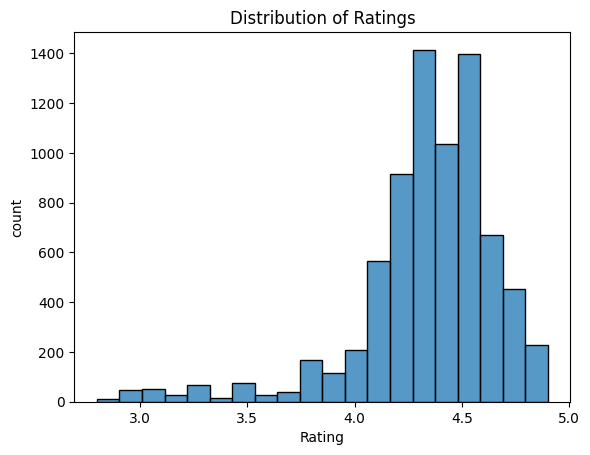

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df_combined['Rating'],bins=20)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('count')
plt.show()

Most restaurants have ratings between 4.0 and 4.6, with a peak around 4.3 to 4.5, indicating that a large number of restaurants are rated highly. The distribution is slightly left-skewed, meaning there are fewer low-rated restaurants compared to high-rated ones.few restaurants have ratings below 3.5, which suggests that poorly rated restaurants are less common in the dataset.dataset is dominated by well-rated restaurants, indicating generally good customer satisfaction.

###Price Distribution

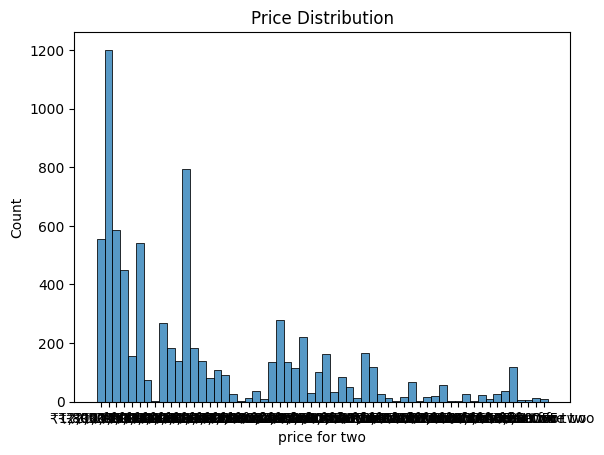

In [ ]:
plt.figure()
sns.histplot(df_combined['Price'], bins=20)
plt.title('Price Distribution')
plt.xlabel('price for two')
plt.show()

The graph shows that the vast majority of restaurants are clustered at the very low end of the price scale, creating a massive budget mountain where most people eat but competition is incredibly fierce.

###Top Cuisines

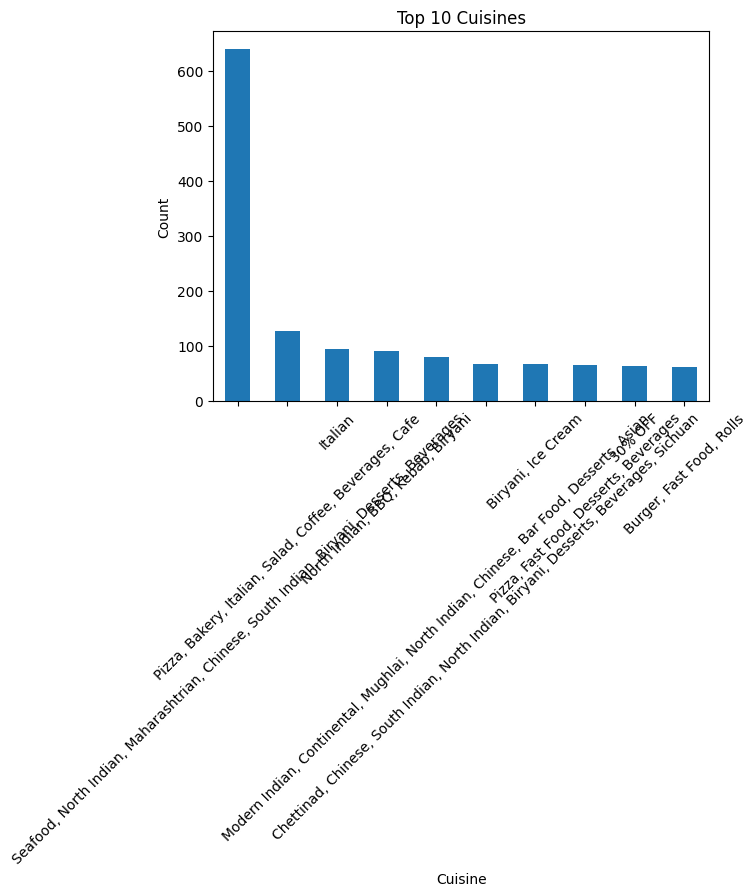

In [ ]:
df_combined["Cuisine"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Cuisines")
plt.xlabel('Cuisine')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

This graph shows that one specific cuisine is a massive "superstar" that dominates the market, with more than triple the count of any other category. For a restaurant owner, this means there is an incredibly high demand for that top item, but it also warns  that the market is already flooded with competitors selling the exact same thing.

### **Reviews Distribution**

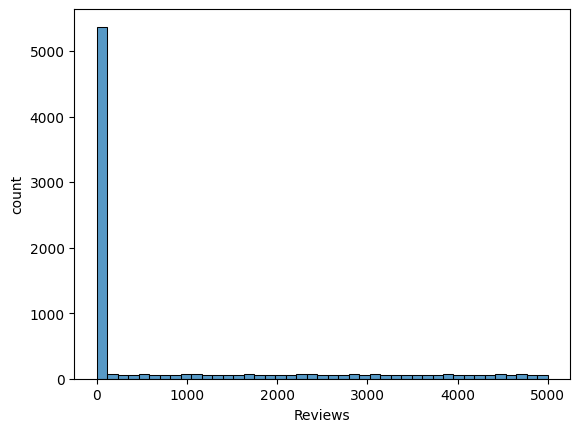

In [ ]:
plt.figure()
sns.histplot(df_combined['Reviews'])
plt.xlabel('Reviews')
plt.ylabel('count')
plt.show()

The graph shows that almost all restaurants have very few reviews, while only a tiny handful have managed to get thousands of customers talking. For a new restaurant, this means getting those first few dozen reviews is the hardest part

###City wise Distribution

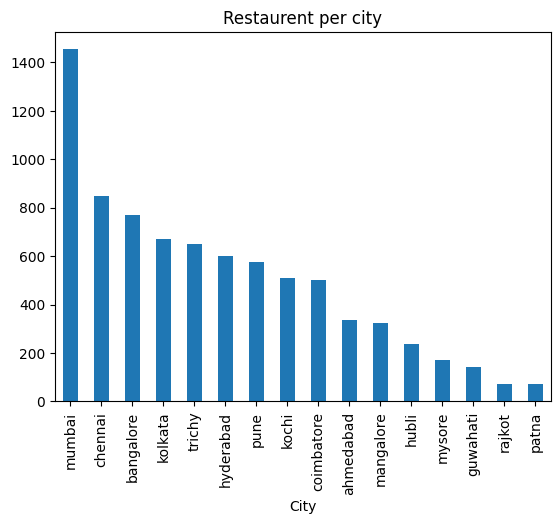

In [ ]:
plt.figure()
df_combined['City'].value_counts().plot(kind='bar')
plt.title('Restaurent per city')
plt.show()

means that while a city like Mumbai has the biggest "pie" and the most hungry customers, you are also entering the most competitive battlefield in the country.

Shows high competition zones
Very useful real-world insight

##**Bivariate Analysis**

###**Reviews vs Rating**

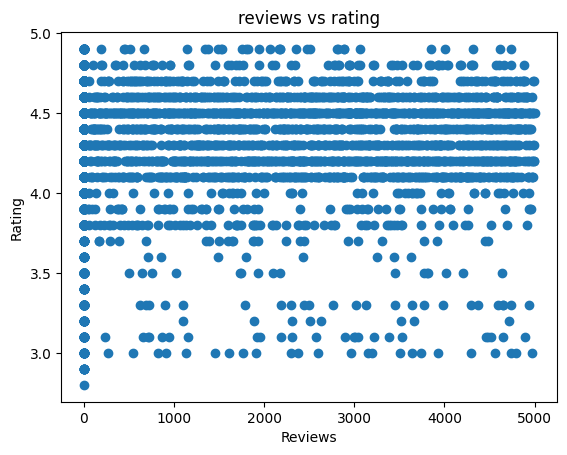

In [ ]:
plt.scatter(df_combined['Reviews'],df_combined['Rating'])
plt.xlabel('Reviews')
plt.ylabel('Rating')
plt.title('reviews vs rating')
plt.show()

his means that "popular" and "good" go hand in hand; if you can survive long enough to get thousands of reviews, you've likely found a formula that people consistently enjoy

### **Cost vs Rating**

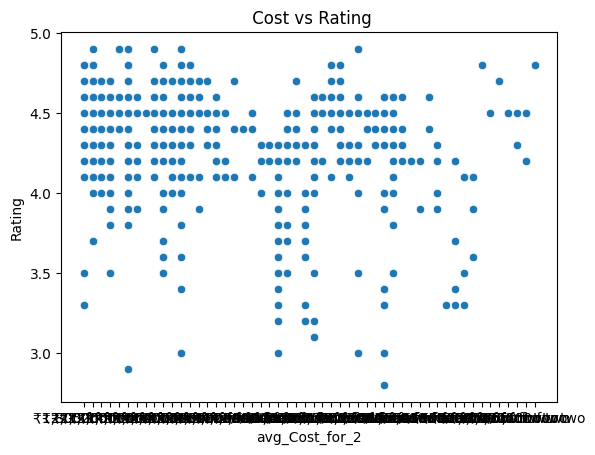

In [ ]:
plt.figure()
sns.scatterplot(x=df_combined['avg_cost_for_2'],y=df_combined['Rating'])
plt.xlabel('avg_Cost_for_2')
plt.ylabel('Rating')
plt.title(' Cost vs Rating')

plt.show()

shows that you don't need to be an expensive restaurant to have a 5-star rating, as there are plenty of top-rated spots even at the lowest price points.

In [ ]:
#Higher price does not always guarantee higher ratings.

###**Online delivery vs Rating**

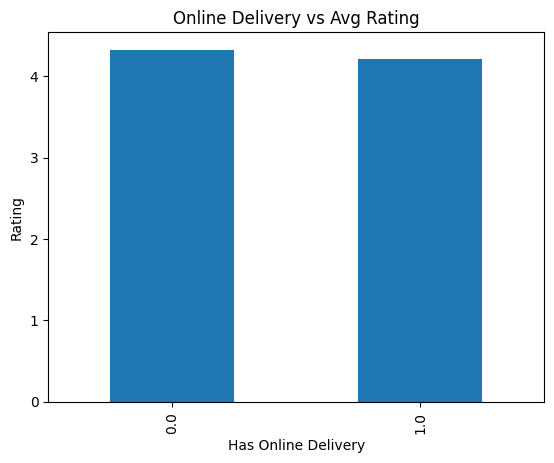

In [ ]:
df_combined.groupby('hasOnlineDelivery')['Rating'].mean().plot(kind='bar')
plt.title("Online Delivery vs Avg Rating")
plt.xlabel("Has Online Delivery")
plt.ylabel("Rating")
plt.show()

while delivery is great for reaching more customers, it won't magically make your food "better" in the eyes of the public. Real success comes from the quality of the service and food itself, regardless of whether its eaten at a table or out of a cardboard box.

###**Table Booking vs Rating**

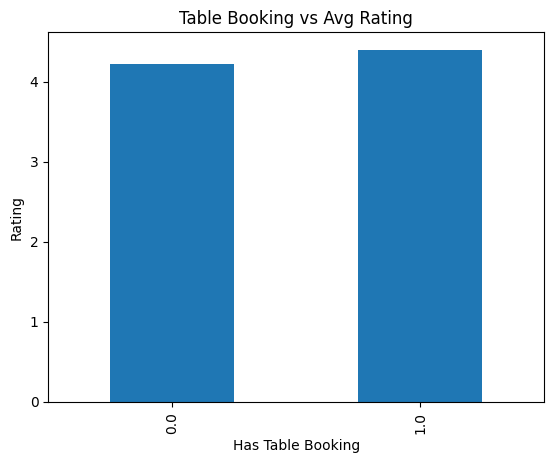

In [ ]:
df_combined.groupby('hasTableBooking')['Rating'].mean().plot(kind='bar')
plt.title("Table Booking vs Avg Rating")
plt.xlabel("Has Table Booking")
plt.ylabel("Rating")
plt.show()

this suggests that the convenience of booking a table creates a better first impression and a more organized dining experience, leading to happier customers

###**Competition Density vs Rating**

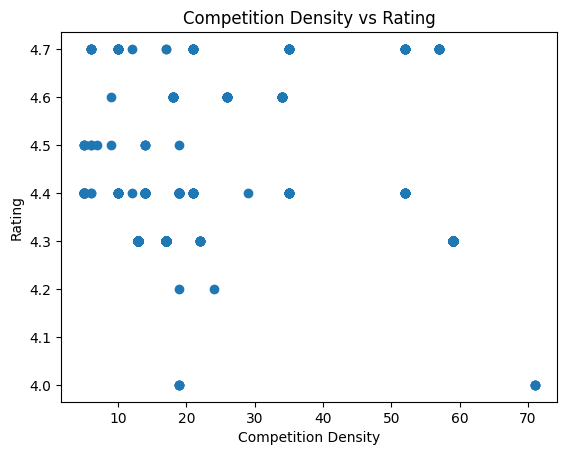

In [ ]:
plt.scatter(df_combined['competition_density_1km'], df_combined['Rating'])
plt.xlabel("Competition Density")
plt.ylabel("Rating")
plt.title("Competition Density vs Rating")
plt.show()

shows that being in a crowded area with lots of other restaurants doesn't automatically kill your rating; in fact, there are highly-rated spots even in areas with very high competition density.